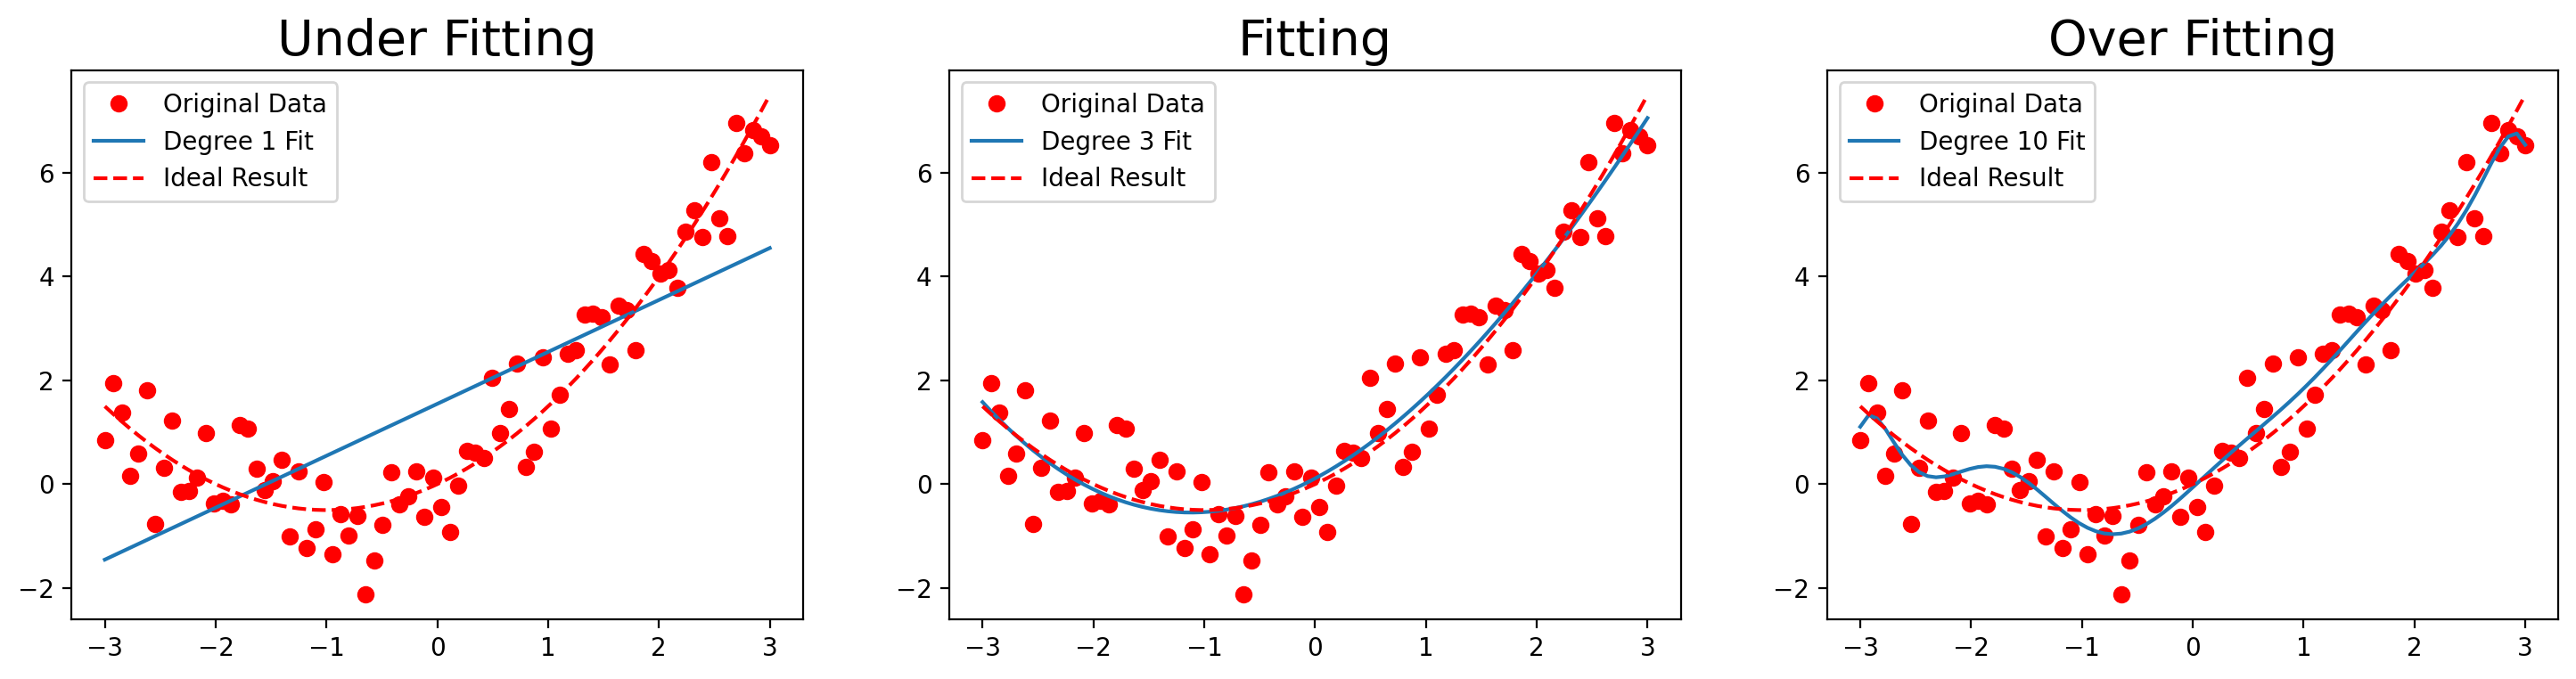

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# 设定随机数种子
np.random.seed(123)

# 创建数据
n = 80 # 样本量，可修改
x = np.linspace(-3, 3, n).reshape(-1, 1)
t = 0.5 * x.ravel()**2 + x.ravel() # 真实的二次关系
y = t + np.random.randn(n) * 0.6 # 添加噪声

def plot_polynomial_fit(x, t, y, deg):
    """
    对给定数据进行多项式拟合，并绘制出原始数据、拟合结果和理想结果的图像。

    参数
    ----------
    x : ndarray
        x坐标的数据
    y : ndarray
        y坐标的数据
    deg : int
        多项式的阶数
    np.polyfit(x, y, deg) :
        对数据点 (x, y) 进行 最小二乘多项式拟合，返回多项式系数
    np.poly1d(...) :
        通过多项式系数构造多项式函数
    """
    # 将x展平为一维，供 np.polyfit 使用
    x_flat = x.ravel()
    # 对数据进行多项式拟合
    p = np.poly1d(np.polyfit(x_flat, y, deg))


    # 绘制原始数据（红色圆点）、拟合结果（蓝色实线）和理想结果（红色虚线）
    plt.plot(x, y, 'ro', label='Original Data')
    plt.plot(x, p(x), '-', label=f'Degree {deg} Fit')
    plt.plot(x, 0.5 * x_flat**2 + x_flat, 'r--', label='Ideal Result')

    # 显示图例
    plt.legend()

plt.figure(figsize=(18, 4), dpi=200)
degrees = [1, 3, 10]  # 多项式的阶数
titles = ['Under Fitting', 'Fitting', 'Over Fitting']  # 图像的标题
for index, deg in enumerate(degrees):
    plt.subplot(1, 3, index + 1)
    plot_polynomial_fit(x, t, y, deg)
    plt.title(titles[index], fontsize=20)

plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.368e+01, tolerance: 4.161e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.523e+01, tolerance: 4.161e-02
  model = cd_fast.enet_coordinate_descent(


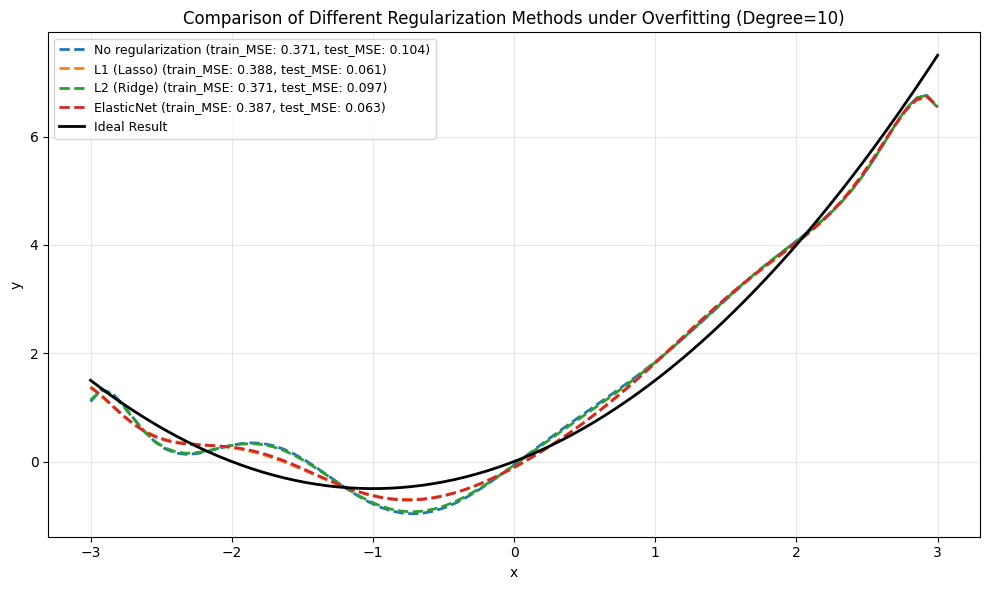

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


# 正则化限制模型的复杂度，以前面degree=10作为过拟合对象进行正则化研究
degree = 10
# PolynomialFeatures(include_bias=False) 避免与线性模型截距重复
models = {
    'No regularization': make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        LinearRegression()
    ),
    'L1 (Lasso)': make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        Lasso(alpha=0.01, max_iter=100000)
    ),
    'L2 (Ridge)': make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        Ridge(alpha=0.1)
    ),
    'ElasticNet': make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=100000)
    )
}

plt. figure(figsize=(10, 6))  # 新建一个图
# 各正则化模型预测曲线
for name, model in models.items():
    model.fit(x, y)

    y_pred = model.predict(x)

    # 训练误差和测试误差
    train_mse = mean_squared_error(y, y_pred)
    test_mse = mean_squared_error(t, y_pred)

    plt.plot(x, y_pred, '--', linewidth=2,
             label=f'{name} (train_MSE: {train_mse:.3f}, test_MSE: {test_mse:.3f})')
# 理想结果曲线
plt.plot(x, 0.5 * x.ravel()**2 + x.ravel(), 'k-', linewidth=2, label='Ideal Result')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Different Regularization Methods under Overfitting (Degree=10)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()